Least square--- Mean Squared error: 5.8815
Least square--- r squared: 0.2257
Polyfit--- Mean Squared error: 3.5433
Polyfit--- r squared: 0.5335
Polyfit method minimizes error better than the least squares approach in this case.
Polyfit fits the curve better than the least squares approach in this case.
The polyfit approach seems to be best for this data.


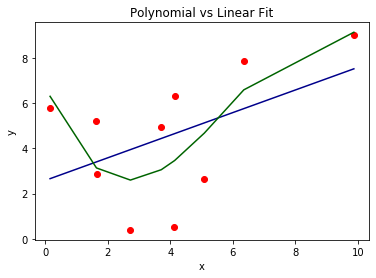

In [10]:
#challenge part A
import random
import numpy as np
import matplotlib.pyplot as plt
#data
list_length = 10
x = np.array([random.uniform(0,10) for _ in range(list_length)])
y = np.array([random.uniform(0,10) for _ in range(list_length)])
x.sort()

#least squares solving

A = np.vstack([x, np.ones(list_length)]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
plt.scatter(x,y, color = "red") #the data points
plt.plot(x, m*x + c, color ="darkblue") #the basic line

mse_ls = np.mean((y - (m*x+c))**2)
print(f'Least square--- Mean Squared error: {mse_ls:.4f}')
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - (m*x+c))**2)
r_squared = 1 - (ss_res / ss_total)
print(f'Least square--- r squared: {r_squared:.4f}')

#polyfit solving
degree = 3
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)
plt.plot(x, y_pred, color='darkgreen', label=f'Polynomial fit of degree {degree}')

mse_poly = np.mean((y - (y_pred))**2)
print(f'Polyfit--- Mean Squared error: {mse_poly:.4f}')
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - (y_pred))**2)
r_squared_poly = 1 - (ss_res / ss_total)
print(f'Polyfit--- r squared: {r_squared_poly:.4f}')

plt.title('Polynomial vs Linear Fit')
plt.xlabel('x')
plt.ylabel('y')

#evaluate which fits better
if mse_ls > mse_poly:
    print("Polyfit method minimizes error better than the least squares approach in this case.")
if mse_poly > mse_ls:
    print("The least squares method minimizes error better than the polyfit approach in this case.")
if r_squared > r_squared_poly:
    print("Least squares fits the curve better than polyfit in this case.")
if r_squared_poly > r_squared:
    print("Polyfit fits the curve better than the least squares approach in this case.")
if mse_ls > mse_poly and r_squared > r_squared_poly:
    print("The least squares approach seems to be best for this data.")
if mse_ls > mse_poly and r_squared_poly > r_squared:
    print("The polyfit approach seems to be best for this data.")
if degree >= list_length:
    print("WARNING: The polynomial is overconditioned, so it is likely to appear as a better fit, but it is poor at predicting new behavior.")
plt.show()

In [4]:
#challenge part B
#for underfit, I am taking the boundary to be r_squared_poly < 0.25, because I don't have another way of knowing the threshold
#for overfit, i am using the condition that we have n datapoints, so n-1 or higher is overfit

#data
list_length = 10
x = np.array([random.uniform(0,10) for _ in range(list_length)])
y = np.array([random.uniform(0,10) for _ in range(list_length)])
x.sort()

#least squares solving
A = np.vstack([x, np.ones(list_length)]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
mse_ls = np.mean((y - (m*x+c))**2)
print(f'Least square--- Mean Squared error: {mse_ls:.4f}')
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - (m*x+c))**2)
r_squared = 1 - (ss_res / ss_total)
print(f'Least square--- r squared: {r_squared:.4f}')

#polyfit solving
degree = 6
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)
mse_poly = np.mean((y - (y_pred))**2)
print(f'Polyfit--- Mean Squared error: {mse_poly:.4f}')
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - (y_pred))**2)
r_squared_poly = 1 - (ss_res / ss_total)
print(f'Polyfit--- r squared: {r_squared_poly:.4f}')

#underfit test
print(" \n\nWe are testing what polynomial is necessary until the data is underfit")
while (r_squared_poly > 0.25 and degree > 0):
    degree -= 1
    print("\nNew polynomial: degree of ", degree)
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(x)
    mse_poly = np.mean((y - (y_pred))**2)
    print(f'Polyfit--- Mean Squared error: {mse_poly:.4f}')
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - (y_pred))**2)
    r_squared_poly = 1 - (ss_res / ss_total)
    print(f'Polyfit--- r squared: {r_squared_poly:.4f}')
    if (r_squared_poly < 0.25):
        print("The data is underfit at a degree of ", degree)
        
#overfit test
degree = 3 #reset the degree to three
print(" \n\nWe are testing what polynomial is necessary until the data is overfit")
while (degree < list_length-1):
    degree += 1
    print("\nNew polynomial: degree of ", degree)
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(x)
    mse_poly = np.mean((y - (y_pred))**2)
    print(f'Polyfit--- Mean Squared error: {mse_poly:.4f}')
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - (y_pred))**2)
    r_squared_poly = 1 - (ss_res / ss_total)
    print(f'Polyfit--- r squared: {r_squared_poly:.4f}')
    if (degree >= list_length-1):
        print("The data is overfit at a degree of ", degree)

Least square--- Mean Squared error: 8.5469
Least square--- r squared: 0.0002
Polyfit--- Mean Squared error: 0.6991
Polyfit--- r squared: 0.9182
 

We are testing what polynomial is necessary until the data is underfit

New polynomial: degree of  5
Polyfit--- Mean Squared error: 2.0246
Polyfit--- r squared: 0.7632

New polynomial: degree of  4
Polyfit--- Mean Squared error: 7.1054
Polyfit--- r squared: 0.1689
The data is underfit at a degree of  4
 

We are testing what polynomial is necessary until the data is overfit

New polynomial: degree of  4
Polyfit--- Mean Squared error: 7.1054
Polyfit--- r squared: 0.1689

New polynomial: degree of  5
Polyfit--- Mean Squared error: 2.0246
Polyfit--- r squared: 0.7632

New polynomial: degree of  6
Polyfit--- Mean Squared error: 0.6991
Polyfit--- r squared: 0.9182

New polynomial: degree of  7
Polyfit--- Mean Squared error: 0.0536
Polyfit--- r squared: 0.9937

New polynomial: degree of  8
Polyfit--- Mean Squared error: 0.0412
Polyfit--- r squared

[[ 1.          0.55659115  0.30979371]
 [ 1.          1.0924207   1.19338298]
 [ 1.          2.16958042  4.70707921]
 [ 1.          2.75933226  7.6139145 ]
 [ 1.          2.93784282  8.63092046]
 [ 1.          2.95734553  8.74589258]
 [ 1.          3.78286001 14.31002988]
 [ 1.          4.11848018 16.96187898]
 [ 1.          5.68859314 32.36009189]
 [ 1.          6.5748381  43.22849611]]
Vandermonde--- Mean Squared error: 5.4058
Vandermonde--- r squared: 0.4412


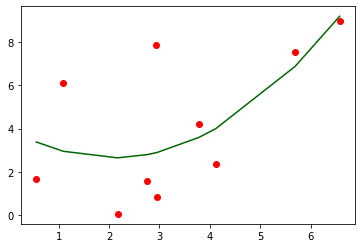

In [7]:
#part C start, vandermonde matrix
import numpy as np
# Create Vandermonde matrix for a polynomial of degree 2
degree = 2
V = np.vander(x, N=degree+1, increasing=True)
print(V)

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)

y_predicted = V @ coefficients

plt.scatter(x,y,color=  "red")
plt.plot(x,y_predicted, color = "darkgreen")
mse_poly = np.mean((y - (y_predicted))**2)
print(f'Vandermonde--- Mean Squared error: {mse_poly:.4f}')
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - (y_predicted))**2)
r_squared_poly = 1 - (ss_res / ss_total)
print(f'Vandermonde--- r squared: {r_squared_poly:.4f}')